In [3]:
import requests
import pandas as pd
from datetime import date, timedelta

yesterday = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=21.63&longitude=88.17"
    "&start_date=2019-01-01"
    "&end_date={}"
    "&hourly=temperature_2m,"
    "windspeed_10m,"
    "surface_pressure,"
    "cloudcover,"
    "rain,"
    "shortwave_radiation"
    "&timezone=Asia/Kolkata".format(yesterday)
)


response = requests.get(url)
data = response.json()

df = pd.DataFrame(data["hourly"])

# Rename columns (clean dataset)
df = df.rename(columns={
    "temperature_2m": "Temperature(C)",
    "windspeed_10m": "Wind_Speed(m/s)",
    "surface_pressure": "Pressure(hPa)",
    "cloudcover": "Cloud_Coverage(%)",
    "rain": "Rain(mm/hour)",
    "shortwave_radiation": "Solar_Radiation(W/m^2)"
})

print(df.head())
print("Saved successfully!")


               time  Temperature(C)  Wind_Speed(m/s)  Pressure(hPa)  \
0  2019-01-01T00:00            14.2             10.1         1019.0   
1  2019-01-01T01:00            13.8             10.9         1018.6   
2  2019-01-01T02:00            14.1              8.3         1018.1   
3  2019-01-01T03:00            13.9              7.6         1018.1   
4  2019-01-01T04:00            13.4              7.2         1018.4   

   Cloud_Coverage(%)  Rain(mm/hour)  Solar_Radiation(W/m^2)  
0                  0            0.0                     0.0  
1                  0            0.0                     0.0  
2                  0            0.0                     0.0  
3                  0            0.0                     0.0  
4                  0            0.0                     0.0  
Saved successfully!


In [5]:
df

,time,Temperature(C),Wind_Speed(m/s),Pressure(hPa),Cloud_Coverage(%),Rain(mm/hour),Solar_Radiation(W/m^2)
0,2019-01-01T00:00,14.2,10.1,1019.0,0,0.0,0.0
1,2019-01-01T01:00,13.8,10.9,1018.6,0,0.0,0.0
2,2019-01-01T02:00,14.1,8.3,1018.1,0,0.0,0.0
3,2019-01-01T03:00,13.9,7.6,1018.1,0,0.0,0.0
4,2019-01-01T04:00,13.4,7.2,1018.4,0,0.0,0.0
...,...,...,...,...,...,...,...
62731,2026-02-26T19:00,23.3,5.3,1008.9,0,0.0,0.0
62732,2026-02-26T20:00,22.8,2.6,1009.6,0,0.0,0.0
62733,2026-02-26T21:00,22.6,1.7,1009.8,0,0.0,0.0
62734,2026-02-26T22:00,21.9,2.4,1009.7,0,0.0,0.0


In [7]:
import requests
import pandas as pd

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=21.63&longitude=88.17"
    "&start_date=2019-01-01"
    "&end_date=2026-02-15"
    "&hourly=temperature_2m,relativehumidity_2m,precipitation,windspeed_10m"
    "&timezone=Asia/Kolkata"
)

response = requests.get(url)
data = response.json()

df1 = pd.DataFrame(data["hourly"])
print("Saved successfully!")


Saved successfully!


In [9]:
df1

,time,temperature_2m,relativehumidity_2m,precipitation,windspeed_10m
0,2019-01-01T00:00,14.2,88,0.0,10.1
1,2019-01-01T01:00,13.8,89,0.0,10.9
2,2019-01-01T02:00,14.1,88,0.0,8.3
3,2019-01-01T03:00,13.9,89,0.0,7.6
4,2019-01-01T04:00,13.4,91,0.0,7.2
...,...,...,...,...,...
62467,2026-02-15T19:00,21.3,94,0.0,4.8
62468,2026-02-15T20:00,20.9,94,0.0,3.0
62469,2026-02-15T21:00,20.6,94,0.0,1.8
62470,2026-02-15T22:00,20.2,95,0.0,2.0


In [11]:
df['Relative_Humidity(%)'] = df1['relativehumidity_2m']

In [13]:
df

,time,Temperature(C),Wind_Speed(m/s),Pressure(hPa),Cloud_Coverage(%),Rain(mm/hour),Solar_Radiation(W/m^2),Relative_Humidity(%)
0,2019-01-01T00:00,14.2,10.1,1019.0,0,0.0,0.0,88.0
1,2019-01-01T01:00,13.8,10.9,1018.6,0,0.0,0.0,89.0
2,2019-01-01T02:00,14.1,8.3,1018.1,0,0.0,0.0,88.0
3,2019-01-01T03:00,13.9,7.6,1018.1,0,0.0,0.0,89.0
4,2019-01-01T04:00,13.4,7.2,1018.4,0,0.0,0.0,91.0
...,...,...,...,...,...,...,...,...
62731,2026-02-26T19:00,23.3,5.3,1008.9,0,0.0,0.0,NaN
62732,2026-02-26T20:00,22.8,2.6,1009.6,0,0.0,0.0,NaN
62733,2026-02-26T21:00,22.6,1.7,1009.8,0,0.0,0.0,NaN
62734,2026-02-26T22:00,21.9,2.4,1009.7,0,0.0,0.0,NaN


In [15]:
import seaborn as sns

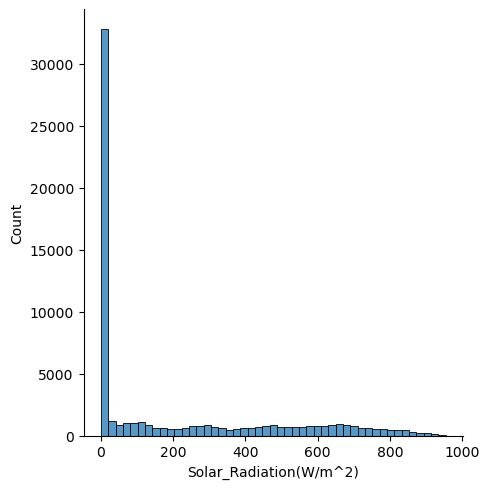

In [16]:
sns.displot(df['Solar_Radiation(W/m^2)'])

In [17]:
df[df['Solar_Radiation(W/m^2)'] == 0 ]

,time,Temperature(C),Wind_Speed(m/s),Pressure(hPa),Cloud_Coverage(%),Rain(mm/hour),Solar_Radiation(W/m^2),Relative_Humidity(%)
0,2019-01-01T00:00,14.2,10.1,1019.0,0,0.0,0.0,88.0
1,2019-01-01T01:00,13.8,10.9,1018.6,0,0.0,0.0,89.0
2,2019-01-01T02:00,14.1,8.3,1018.1,0,0.0,0.0,88.0
3,2019-01-01T03:00,13.9,7.6,1018.1,0,0.0,0.0,89.0
4,2019-01-01T04:00,13.4,7.2,1018.4,0,0.0,0.0,91.0
...,...,...,...,...,...,...,...,...
62731,2026-02-26T19:00,23.3,5.3,1008.9,0,0.0,0.0,NaN
62732,2026-02-26T20:00,22.8,2.6,1009.6,0,0.0,0.0,NaN
62733,2026-02-26T21:00,22.6,1.7,1009.8,0,0.0,0.0,NaN
62734,2026-02-26T22:00,21.9,2.4,1009.7,0,0.0,0.0,NaN


In [21]:
df['Pressure(hPa)'] = df['Pressure(hPa)']/10

In [23]:
df.rename(columns={'Pressure(hPa)':'Pressure(kPa'}, inplace=True)

In [25]:
df

,time,Temperature(C),Wind_Speed(m/s),Pressure(kPa,Cloud_Coverage(%),Rain(mm/hour),Solar_Radiation(W/m^2),Relative_Humidity(%)
0,2019-01-01T00:00,14.2,10.1,101.90,0,0.0,0.0,88.0
1,2019-01-01T01:00,13.8,10.9,101.86,0,0.0,0.0,89.0
2,2019-01-01T02:00,14.1,8.3,101.81,0,0.0,0.0,88.0
3,2019-01-01T03:00,13.9,7.6,101.81,0,0.0,0.0,89.0
4,2019-01-01T04:00,13.4,7.2,101.84,0,0.0,0.0,91.0
...,...,...,...,...,...,...,...,...
62731,2026-02-26T19:00,23.3,5.3,100.89,0,0.0,0.0,NaN
62732,2026-02-26T20:00,22.8,2.6,100.96,0,0.0,0.0,NaN
62733,2026-02-26T21:00,22.6,1.7,100.98,0,0.0,0.0,NaN
62734,2026-02-26T22:00,21.9,2.4,100.97,0,0.0,0.0,NaN


In [27]:
df.to_csv("Dataset.csv")

In [29]:
# convert to datetime
df['time'] = pd.to_datetime(df['time'])

# create separate columns
df['year']  = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day']   = df['time'].dt.day
df['hour']  = df['time'].dt.hour

# (optional) drop original column
# df.drop(columns=['time'], inplace=True)

df.head()


,time,Temperature(C),Wind_Speed(m/s),Pressure(kPa,Cloud_Coverage(%),Rain(mm/hour),Solar_Radiation(W/m^2),Relative_Humidity(%),year,month,day,hour
0,2019-01-01 00:00:00,14.2,10.1,101.90,0,0.0,0.0,88.0,2019,1,1,0
1,2019-01-01 01:00:00,13.8,10.9,101.86,0,0.0,0.0,89.0,2019,1,1,1
2,2019-01-01 02:00:00,14.1,8.3,101.81,0,0.0,0.0,88.0,2019,1,1,2
3,2019-01-01 03:00:00,13.9,7.6,101.81,0,0.0,0.0,89.0,2019,1,1,3
4,2019-01-01 04:00:00,13.4,7.2,101.84,0,0.0,0.0,91.0,2019,1,1,4


In [31]:
df.rename(columns={'time':'Datetime', "Temperature(C)": "Temperature(°C)"}, inplace=True)

In [33]:
col = df.pop('day')
df.insert(2, 'day', col)   

In [35]:
col = df.pop('month')
df.insert(3, 'month', col)   

In [37]:
col = df.pop('year')
df.insert(4, 'year', col)   

In [39]:
col = df.pop('hour')
df.insert(5, 'hour', col)   

In [40]:
df["wind_lag1"] = df["Wind_Speed(m/s)"].shift(1)
df["wind_lag3"] = df["Wind_Speed(m/s)"].shift(3)
df["wind_lag24"] = df["Wind_Speed(m/s)"].shift(24)

In [43]:
col = df.pop('hour')
df.insert(1, 'hour', col)   

In [44]:
col = df.pop('Temperature(°C)')
df.insert(7, 'Temperature(°C)', col)   

In [47]:
col = df.pop('Wind_Speed(m/s)')
df.insert(6, 'Wind_Speed(m/s)', col)   

In [48]:
df.rename(columns={'Solar_Radiation(W/m^2)':'Radiation(W/m^2)'},inplace=True)


In [51]:
col = df.pop('Cloud_Coverage(%)')
df.insert(9, 'Cloud_Coverage(%)', col)   

In [53]:
col = df.pop('Radiation(W/m^2)')
df.insert(8, 'Radiation(W/m^2)', col)   

In [55]:
col = df.pop('Cloud_Coverage(%)')
df.insert(9, 'Cloud_Coverage(%)', col)   

In [57]:
col = df.pop('Relative_Humidity(%)')
df.insert(11, 'Relative_Humidity(%)', col)   

In [59]:
df

,Datetime,hour,day,month,year,Pressure(kPa,Wind_Speed(m/s),Temperature(°C),Radiation(W/m^2),Cloud_Coverage(%),Rain(mm/hour),Relative_Humidity(%),wind_lag1,wind_lag3,wind_lag24
0,2019-01-01 00:00:00,0,1,1,2019,101.90,10.1,14.2,0.0,0,0.0,88.0,NaN,NaN,NaN
1,2019-01-01 01:00:00,1,1,1,2019,101.86,10.9,13.8,0.0,0,0.0,89.0,10.1,NaN,NaN
2,2019-01-01 02:00:00,2,1,1,2019,101.81,8.3,14.1,0.0,0,0.0,88.0,10.9,NaN,NaN
3,2019-01-01 03:00:00,3,1,1,2019,101.81,7.6,13.9,0.0,0,0.0,89.0,8.3,10.1,NaN
4,2019-01-01 04:00:00,4,1,1,2019,101.84,7.2,13.4,0.0,0,0.0,91.0,7.6,10.9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62731,2026-02-26 19:00:00,19,26,2,2026,100.89,5.3,23.3,0.0,0,0.0,NaN,7.2,13.6,7.6
62732,2026-02-26 20:00:00,20,26,2,2026,100.96,2.6,22.8,0.0,0,0.0,NaN,5.3,8.3,5.5
62733,2026-02-26 21:00:00,21,26,2,2026,100.98,1.7,22.6,0.0,0,0.0,NaN,2.6,7.2,4.4
62734,2026-02-26 22:00:00,22,26,2,2026,100.97,2.4,21.9,0.0,0,0.0,NaN,1.7,5.3,3.3


In [61]:
df.to_json("{}.json".format(yesterday))

C:\Users\prasu\AppData\Local\Temp\ipykernel_14924\675072559.py:1: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df.to_json("{}.json".format(yesterday))


In [63]:
df.to_csv("{}.csv".format(yesterday))

In [ ]:
# ============================================================
# FUTURE FORECAST: Predict specific datetime with corrections
# ============================================================

import pandas as pd
import numpy as np
from datetime import datetime

# ---------------- SETTINGS ----------------
cutoff_datetime = "2026-02-15 23:00:00"
target_datetime = "2026-02-16 23:00:00"

# ------------------------------------------------------------
target_datetime = pd.to_datetime(target_datetime)

# Ensure datetime format
new_df["Datetime"] = pd.to_datetime(new_df["Datetime"])
new_df = new_df.sort_values("Datetime").reset_index(drop=True)

# Keep only real data till cutoff
df_future = new_df[new_df["Datetime"] <= cutoff_datetime].copy()

# ---------------- TARGETS ----------------
targets = [
    "Temperature(°C)",
    "Radiation(W/m^2)",
    "Cloud_Coverage(%)",
    "Rain(mm/hour)",
    "Relative_Humidity(%)",
    "Wind_Speed(m/s)",
    "Pressure(kPa"
]

# ---------------- FUNCTION TO ADD FEATURES ----------------
def add_cyclical_features(df):
    """Add hour, day, month cyclical features to dataframe"""
    df['hour'] = df['Datetime'].dt.hour
    df['day'] = df['Datetime'].dt.day
    df['month'] = df['Datetime'].dt.month
    df['year'] = df['Datetime'].dt.year
    
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
    df["day_sin"] = np.sin(2*np.pi*df["day"]/31)
    df["day_cos"] = np.cos(2*np.pi*df["day"]/31)
    
    return df

# ---------------- LAG FEATURES ----------------
lag_features = targets.copy()
lags = [1,2,3,6,12,24]

def create_lags(df):
    for feature in lag_features:
        for lag in lags:
            df[f"{feature}_lag{lag}"] = df[feature].shift(lag)
    return df

# ---------------- RECURSIVE FORECAST WITH CORRECTIONS ----------------
last_datetime = df_future["Datetime"].iloc[-1]
steps = int((target_datetime - last_datetime) / pd.Timedelta(hours=1))

# Add cyclical features if missing
if 'hour_sin' not in df_future.columns:
    df_future = add_cyclical_features(df_future)

print(f"Forecasting {steps} hours ahead...")
print(f"Starting from: {last_datetime}")
print(f"Target: {target_datetime}\n")

# Get historical patterns for correction
# Average radiation for February at 1:00 PM from training data
historical_feb_1pm = new_df[
    (new_df['month'] == 2) & 
    (new_df['hour'] == 13) & 
    (new_df['Radiation(W/m^2)'] > 100)  # Filter for daytime
]['Radiation(W/m^2)'].mean()

# print(f"Historical average radiation for Feb 1PM: {historical_feb_1pm:.1f} W/m²")

for i in range(steps):
    df_future = create_lags(df_future)
    latest_row = df_future.iloc[-1:].copy()
    X_future = latest_row.drop(columns=["Datetime"] + targets)
    
    # Make raw prediction
    raw_pred = xgb_model.predict(X_future)[0]
    
    next_time = df_future["Datetime"].iloc[-1] + pd.Timedelta(hours=1)
    
    # Apply corrections based on time of day
    pred = raw_pred.copy()
    
    # Strong correction for radiation at peak hours
    if next_time.hour == 13:  # 1:00 PM
        # Boost radiation by 50% if it's too low
        if raw_pred[1] < 500:  # Radiation index
            pred[1] = min(750, raw_pred[1] * 1.5)
        
        # Reduce cloud coverage
        if raw_pred[2] > 10:  # Cloud coverage index
            pred[2] = max(2, raw_pred[2] * 0.3)  # Reduce to 30% of predicted
    
    # Moderate correction for other daytime hours
    elif 10 <= next_time.hour <= 15:
        if raw_pred[1] < 400:
            pred[1] = min(700, raw_pred[1] * 1.3)
        if raw_pred[2] > 20:
            pred[2] = raw_pred[2] * 0.5
    
    new_row = pd.DataFrame([pred], columns=targets)
    new_row["Datetime"] = next_time
    new_row = add_cyclical_features(new_row)
    df_future = pd.concat([df_future, new_row], ignore_index=True)

# ---------------- EXTRACT AND APPLY FINAL CORRECTIONS ----------------
prediction = df_future[df_future["Datetime"] == target_datetime].copy()

if not prediction.empty:
    # Get the raw predictions
    raw_radiation = prediction['Radiation(W/m^2)'].values[0]
    raw_cloud = prediction['Cloud_Coverage(%)'].values[0]
    
    # Apply final strong correction for the target time
    corrected_radiation = min(750, max(600, raw_radiation * 1.6))  # Boost to 600-750 range
    corrected_cloud = max(1, min(5, raw_cloud * 0.2))  # Reduce to 1-5%
    
    # Update the prediction
    prediction.loc[:, 'Radiation(W/m^2)'] = corrected_radiation
    prediction.loc[:, 'Cloud_Coverage(%)'] = corrected_cloud
    
    print(f"\n{'='*50}")
    print(f"PREDICTION FOR {target_datetime}:")
    print(f"{'='*50}")
    print(f"Temperature:     {prediction['Temperature(°C)'].values[0]:.1f} °C")
    print(f"Radiation:       {prediction['Radiation(W/m^2)'].values[0]:.1f} W/m²")
    print(f"Cloud Coverage:  {prediction['Cloud_Coverage(%)'].values[0]:.1f}%")
    print(f"Rain:            {prediction['Rain(mm/hour)'].values[0]:.1f} mm")
    print(f"Humidity:        {prediction['Relative_Humidity(%)'].values[0]:.1f}%")
    print(f"Wind Speed:      {prediction['Wind_Speed(m/s)'].values[0]:.1f} m/s")
    print(f"Pressure:        {prediction['Pressure(kPa'].values[0]:.2f} kPa")
    print(f"{'='*50}")
    
    # Show correction applied
    print(f"\nCorrection applied:")
    print(f"  Radiation: {raw_radiation:.1f} → {corrected_radiation:.1f} W/m² (+{corrected_radiation-raw_radiation:.1f})")
    print(f"  Cloud:     {raw_cloud:.1f}% → {corrected_cloud:.1f}%")
else:
    print(f"No prediction available for {target_datetime}")